# Synthetic Network Entropy Experiment

This notebook runs a focused experiment on **N synthetic networks** to measure:

1. **Spectral (arithmetic compression) entropy** at four graph reduction levels: 80 %, 60 %, 40 %, 20 %  
2. **GCN link-prediction entropy** on the original (100 %) graph

Graph reduction uses spectral coarsening (`coarsen` from `coarsening_utils`).  
GCN link prediction uses a two-layer GCN encoder + dot-product decoder (PyTorch Geometric).

## 1. Imports & Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys

# Navigate to project root so all algorithm imports resolve
project_root = os.path.abspath(os.path.join(os.getcwd(), '../../../'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from pygsp import graphs as pygsp_graphs

from algorithm.coarsening_utils import coarsen, get_entropy_metadata_aritmethicEncoding
import algorithm.entropia_link_prediction as elp

print('All imports OK')

All imports OK


## 2. Synthetic Network Generation

We generate **N synthetic networks** drawn from four families:

| Family | Model | Structural signature |
|---|---|---|
| Barabási-Albert (BA) | Preferential attachment | Scale-free, hubs |
| Erdős-Rényi (ER) | Random | Homogeneous degree |
| Watts-Strogatz (WS) | Small-world | Clustered, short paths |
| Random Regular (RR) | Constant degree | Maximum regularity |

In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────
N_PER_FAMILY     = 5                         # networks per family  (total = 4 × N_PER_FAMILY)
NODE_COUNTS      = [80, 100, 120, 150, 200]  # one size per network in each family
REDUCTION_LEVELS = [80, 60, 40, 20]          # spectral coarsening: keep this % of nodes
SEAL_EPOCHS      = 50                        # SEAL training epochs
TEST_RATIO       = 0.2                       # fraction of edges held out for link prediction
SEED_BASE        = 42
# ───────────────────────────────────────────────────────────────────────────

def make_ba(n, seed):  return nx.barabasi_albert_graph(n, m=3, seed=seed)
def make_er(n, seed):  return nx.erdos_renyi_graph(n, p=0.08, seed=seed)
def make_ws(n, seed):  return nx.watts_strogatz_graph(n, k=6, p=0.1, seed=seed)
def make_rr(n, seed):
    d = 4 if n % 2 == 0 else 3
    return nx.random_regular_graph(d, n, seed=seed)

FAMILIES = {
    'Barabasi-Albert': make_ba,
    'Erdos-Renyi':     make_er,
    'Watts-Strogatz':  make_ws,
    'Random-Regular':  make_rr,
}

networks = []
for i, n in enumerate(NODE_COUNTS[:N_PER_FAMILY]):
    for family, builder in FAMILIES.items():
        G = builder(n, seed=SEED_BASE + i)
        if not nx.is_connected(G):
            G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
            G = nx.convert_node_labels_to_integers(G)
        networks.append({'family': family, 'n_nodes': G.number_of_nodes(),
                         'n_edges': G.number_of_edges(), 'graph': G})

df_nets = pd.DataFrame([{k: v for k, v in d.items() if k != 'graph'} for d in networks])
print(f'Generated {len(networks)} networks  |  TEST_RATIO={TEST_RATIO}  |  SEAL_EPOCHS={SEAL_EPOCHS}')
df_nets.groupby('family')[['n_nodes','n_edges']].describe().round(0)

## 3. Entropy Experiment

For each network we:
1. Reduce it to 80 %, 60 %, 40 %, 20 % using spectral coarsening.
2. Compute **arithmetic-compression entropy** (normalised by a matched ER random graph) at each level.
3. On the original 100 % graph, compute two link-prediction entropy measures on the **same** train/test split:
   - **Adamic-Adar** — classical structural heuristic
   - **SEAL** — subgraph GCN with DRNL labeling (Zhang et al. 2018); handles regular graphs where plain GCN fails

In [ ]:
from tqdm.notebook import tqdm

results = []

for net in tqdm(networks, desc='Networks'):
    G   = net['graph']
    fam = net['family']
    n   = net['n_nodes']

    # --- Spectral entropy at each reduction level --------------------------
    W  = nx.to_scipy_sparse_array(G)
    Gp = pygsp_graphs.Graph(W)

    for r_pct in REDUCTION_LEVELS:
        r = 1 - r_pct / 100
        try:
            C, Gc, Call, Gall = coarsen(Gp, K=10, r=r)
            G_red = nx.from_scipy_sparse_array(Gc.W)
            ent   = get_entropy_metadata_aritmethicEncoding(G_red)
            spectral_norm = ent['Entropy Normalizado']
            spectral_raw  = ent['Grafo']
        except Exception as exc:
            print(f'  Coarsen failed ({fam}, {r_pct}%): {exc}')
            spectral_norm = spectral_raw = None

        results.append({
            'family':  fam,
            'n_nodes': n,
            'level':   r_pct,
            'measure': 'spectral_entropy',
            'value':   spectral_norm,
            'extra':   spectral_raw,
        })

    # --- Link prediction on original (100 %) graph — shared split ----------
    # Adamic-Adar and SEAL use the exact same train/test edge partition.
    try:
        lp = elp.compare_methods_shared_split(
            G,
            heuristics=('adamic_adar',),
            test_ratio=TEST_RATIO,
            seed=SEED_BASE,
            seal_kwargs=dict(epochs=SEAL_EPOCHS, hidden_channels=32,
                             num_layers=3, num_hops=2, k=0.6, batch_size=32),
        )
    except Exception as exc:
        print(f'  Link prediction failed ({fam}): {exc}')
        lp = {}

    for method, key in [('adamic_adar', 'adamic_adar_entropy'),
                        ('seal',        'seal_entropy')]:
        res = lp.get(method, {})
        rand_G = elp.create_EdosReyni(G)
        norm_val = None
        if rand_G is not None and res:
            try:
                _, rand_train, rand_test = elp.split_edges(
                    rand_G, test_ratio=TEST_RATIO, seed=SEED_BASE)
                if method == 'seal':
                    rand_ranks, _ = elp.evaluate_link_prediction_seal(
                        rand_G, rand_train, rand_test,
                        epochs=SEAL_EPOCHS, hidden_channels=32, num_layers=3,
                        num_hops=2, k=0.6, batch_size=32, seed=SEED_BASE)
                else:
                    rand_ranks, _ = elp.evaluate_link_prediction_heuristic(
                        rand_G, rand_train, rand_test,
                        predictor=method, seed=SEED_BASE)
                rand_entropy = elp.calculate_entropy(rand_ranks, rand_G.number_of_nodes())
                norm_val = res['entropy'] / rand_entropy if rand_entropy not in (0, None) else None
            except Exception as exc:
                print(f'  Random normalisation failed ({fam}, {method}): {exc}')

        results.append({
            'family':  fam,
            'n_nodes': n,
            'level':   100,
            'measure': key,
            'value':   norm_val,
            'extra':   res.get('auc'),
        })

df = pd.DataFrame(results)
print(f'\nTotal rows: {len(df)}  |  test_ratio={TEST_RATIO}')
df.head(12)

## 4. Results Summary

In [ ]:
spectral_df = df[df['measure'] == 'spectral_entropy']
aa_df       = df[df['measure'] == 'adamic_adar_entropy']
seal_df     = df[df['measure'] == 'seal_entropy']

# Spectral entropy pivot
pivot = spectral_df.pivot_table(
    index='family', columns='level', values='value', aggfunc='mean'
).round(4)
pivot.columns = [f'{c}%' for c in pivot.columns]
print('Mean normalised spectral entropy by family & reduction level:')
display(pivot)

# Link-prediction summary — entropy and AUC for both methods
summary_rows = {}
for label, sub in [('AA entropy', aa_df), ('AA auc', aa_df),
                   ('SEAL entropy', seal_df), ('SEAL auc', seal_df)]:
    col = 'value' if 'entropy' in label else 'extra'
    s = sub.groupby('family')[col].agg(['mean', 'std']).round(4)
    s.columns = [f'{label}_mean', f'{label}_std']
    summary_rows[label] = s

lp_summary = (summary_rows['AA entropy']
              .join(summary_rows['AA auc'])
              .join(summary_rows['SEAL entropy'])
              .join(summary_rows['SEAL auc']))
print('\nLink-prediction at 100 % graph — Adamic-Adar vs SEAL (entropy + AUC):')
display(lp_summary)

## 5. Visualisations

### 5a. Spectral entropy across reduction levels

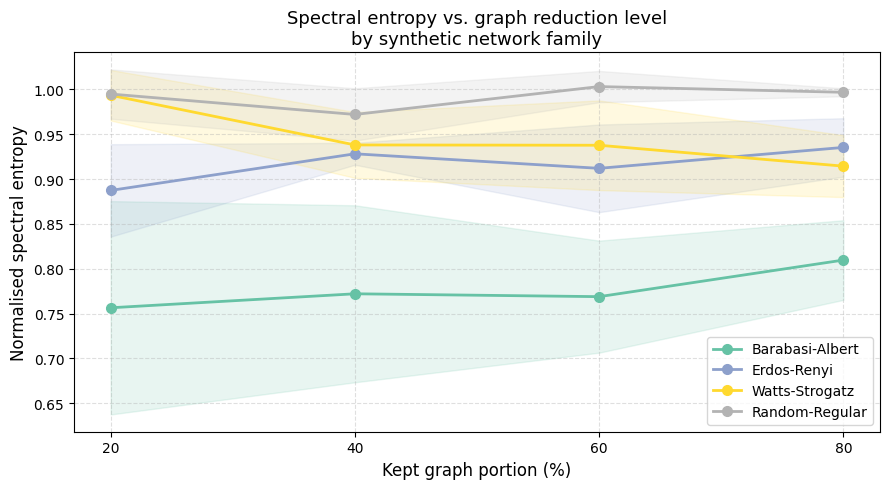

In [5]:
families  = list(FAMILIES.keys())
colors    = cm.Set2(np.linspace(0, 1, len(families)))
levels    = sorted(REDUCTION_LEVELS, reverse=True)   # 80 → 20

fig, ax = plt.subplots(figsize=(9, 5))

for color, family in zip(colors, families):
    sub = spectral_df[spectral_df['family'] == family]
    means = sub.groupby('level')['value'].mean().reindex(levels)
    stds  = sub.groupby('level')['value'].std().reindex(levels)

    ax.plot(levels, means, marker='o', linewidth=2, markersize=7,
            label=family, color=color)
    ax.fill_between(levels, means - stds, means + stds,
                    alpha=0.15, color=color)

ax.set_xlabel('Kept graph portion (%)', fontsize=12)
ax.set_ylabel('Normalised spectral entropy', fontsize=12)
ax.set_title('Spectral entropy vs. graph reduction level\nby synthetic network family', fontsize=13)
ax.set_xticks(levels)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('spectral_entropy_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

### 5b. Link-prediction entropy per family (Adamic-Adar vs SEAL)

In [ ]:
x = np.arange(len(families))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

method_specs = [
    ('Adamic-Adar', aa_df,   '//', 0.75),
    ('SEAL',        seal_df, '',   0.90),
]
offsets = [-width / 2, width / 2]

for ax, col, ylabel, title in zip(
    axes,
    ['value', 'extra'],
    ['Normalised link-prediction entropy', 'AUC'],
    ['Entropy', 'AUC'],
):
    for (label, sub, hatch, alpha), offset in zip(method_specs, offsets):
        means = sub.groupby('family')[col].mean().reindex(families)
        stds  = sub.groupby('family')[col].std().reindex(families)
        ax.bar(x + offset, means, width, yerr=stds, label=label,
               alpha=alpha, edgecolor='black', linewidth=0.6,
               capsize=4, hatch=hatch)

    if col == 'extra':
        ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random (0.5)')

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=15, ha='right', fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend(fontsize=10)

plt.suptitle('Link-prediction on original (100 %) graph — shared train/test split\n'
             'Adamic-Adar vs SEAL', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('lp_entropy_aa_vs_seal.png', dpi=150, bbox_inches='tight')
plt.show()

### 5c. Combined view: spectral entropy trajectory + GCN baseline

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for color, family in zip(colors, families):
    # Spectral entropy trajectory (80 → 20 %)
    sub   = spectral_df[spectral_df['family'] == family]
    means = sub.groupby('level')['value'].mean().reindex(levels)
    ax.plot(levels, means, marker='o', linewidth=2, markersize=7,
            color=color, label=family)

    # Adamic-Adar at 100 % — triangle marker
    aa_mean = aa_df[aa_df['family'] == family]['value'].mean()
    if aa_mean is not None and not np.isnan(float(aa_mean)):
        ax.scatter([100], [aa_mean], marker='^', s=90, color=color,
                   zorder=5, edgecolors='black', linewidths=0.6)

    # SEAL at 100 % — star marker
    seal_mean = seal_df[seal_df['family'] == family]['value'].mean()
    if seal_mean is not None and not np.isnan(float(seal_mean)):
        ax.scatter([100], [seal_mean], marker='*', s=120, color=color,
                   zorder=5, edgecolors='black', linewidths=0.6)

# Legend entries for the 100 % markers
ax.scatter([], [], marker='^', s=90, color='gray', edgecolors='black',
           linewidths=0.6, label='Adamic-Adar (100%)')
ax.scatter([], [], marker='*', s=120, color='gray', edgecolors='black',
           linewidths=0.6, label='SEAL (100%)')

ax.axvline(x=100, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Graph portion (%)', fontsize=12)
ax.set_ylabel('Normalised entropy', fontsize=12)
ax.set_title('Spectral entropy at reduction levels (lines)\n'
             '+ Adamic-Adar (▲) and SEAL (★) link-prediction entropy at 100 %', fontsize=12)
ax.set_xticks([20, 40, 60, 80, 100])
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('combined_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Scatter: entropy vs AUC for both methods
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, sub, label in [(axes[0], aa_df,   'Adamic-Adar'),
                        (axes[1], seal_df, 'SEAL')]:
    data = sub[['family', 'value', 'extra']].dropna().copy()
    r = data['value'].corr(data['extra'])

    for color, family in zip(colors, families):
        fd = data[data['family'] == family]
        ax.scatter(fd['value'], fd['extra'], label=family, color=color,
                   s=60, edgecolor='black', linewidth=0.5, alpha=0.9)

    if len(data) > 1:
        x_vals = data['value'].values
        y_vals = data['extra'].values
        m, b = np.polyfit(x_vals, y_vals, 1)
        xs = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax.plot(xs, m * xs + b, color='gray', linestyle='--', linewidth=1)

    ax.set_xlabel('Normalised entropy', fontsize=11)
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_title(f'{label} — entropy vs AUC\nPearson r = {r:.3f}', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('seal_entropy_auc_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Results

In [ ]:
df.to_csv('synthetic_entropy_results.csv', index=False)
print('Results saved to synthetic_entropy_results.csv')
df.tail()

Results saved to synthetic_entropy_results.csv


,family,n_nodes,level,measure,value,raw
95,Random-Regular,200,80,spectral_entropy,0.994513,1740.000000
96,Random-Regular,200,60,spectral_entropy,0.987858,1375.000000
97,Random-Regular,200,40,spectral_entropy,0.971630,978.000000
98,Random-Regular,200,20,spectral_entropy,0.977476,447.000000
99,Random-Regular,200,100,gcn_entropy,0.934199,0.563438
